E-2: rifare l'esercizio E-1 con learning rate 0,001 - 0,01 - 0,1 - 1 - 10 e descrivere a parole cosa succede in ciascun caso

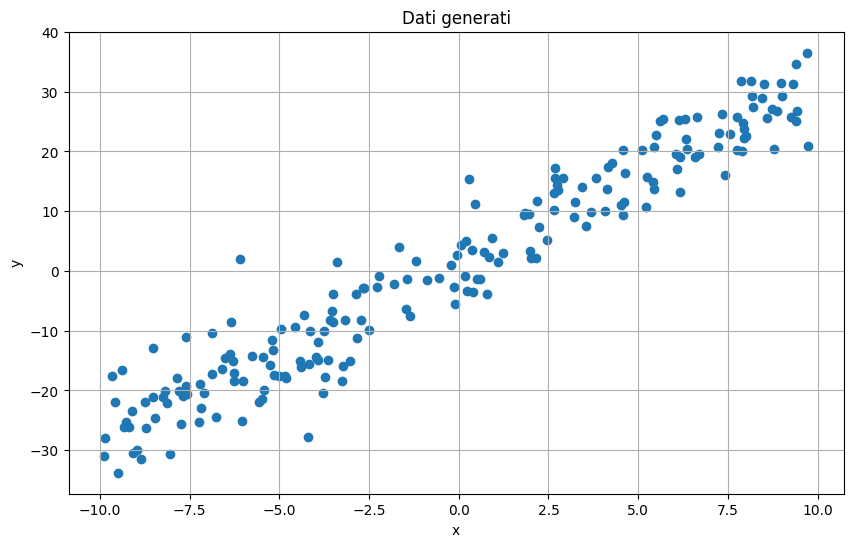

Learning Rate: 0.001
MSE iniziale: 330.9423362176781
MSE finale: 24.58612600745569
m: 2.967697359286357
q: 0.21775425040773466


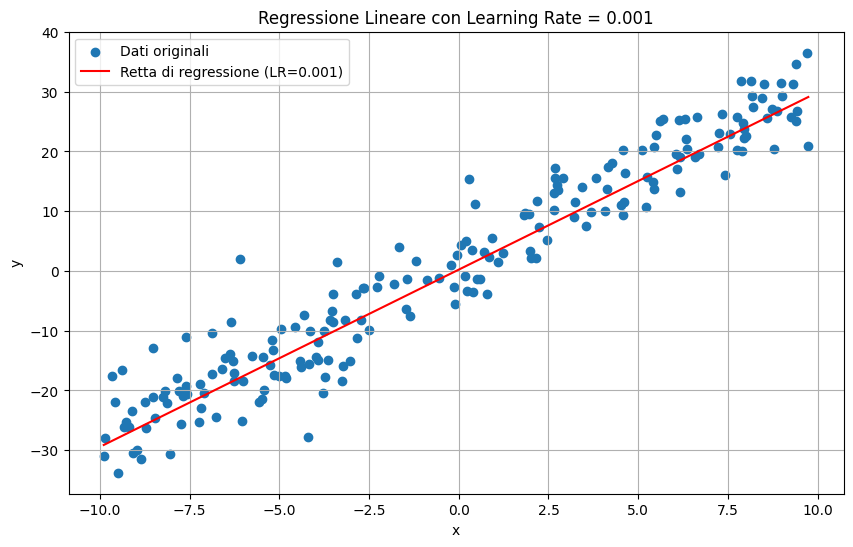

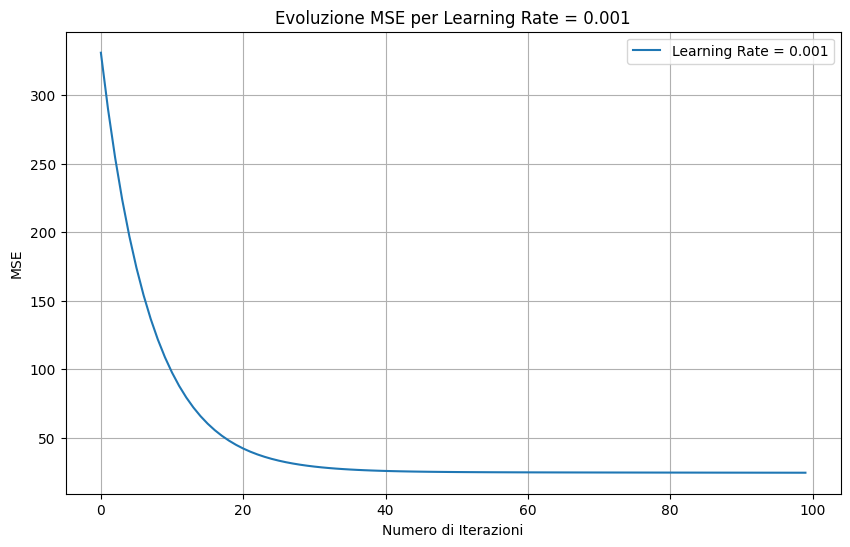

Learning Rate: 0.01
MSE iniziale: 330.9423362176781
MSE finale: 23.37979282380651
m: 2.9787617186065054
q: 1.1494807336293502


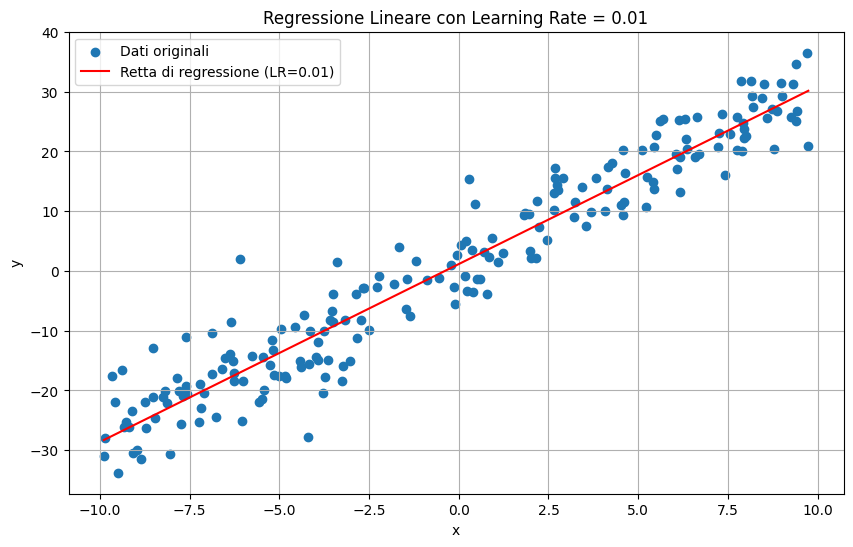

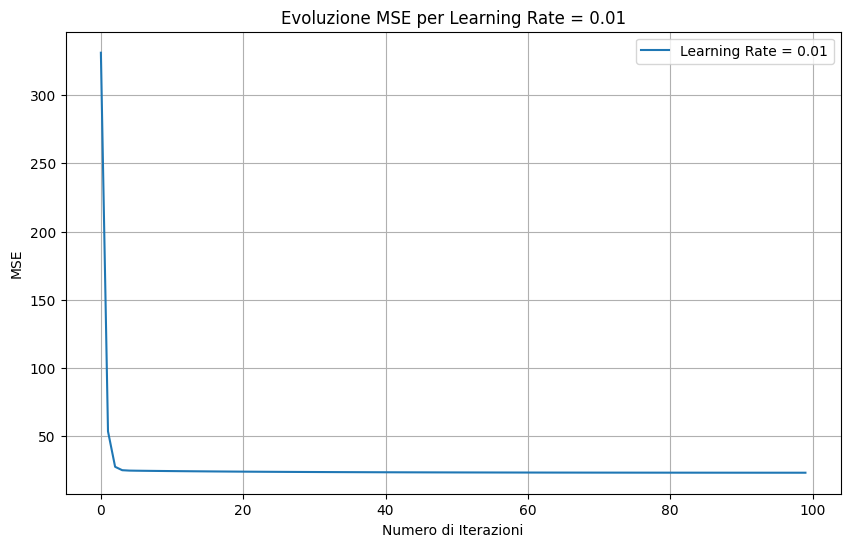

Learning Rate: 0.1
Divergenza!
MSE iniziale: 330.9423362176781
MSE finale: 16809332749.544905
m: 22006.488313883812
q: -207.8722343253703


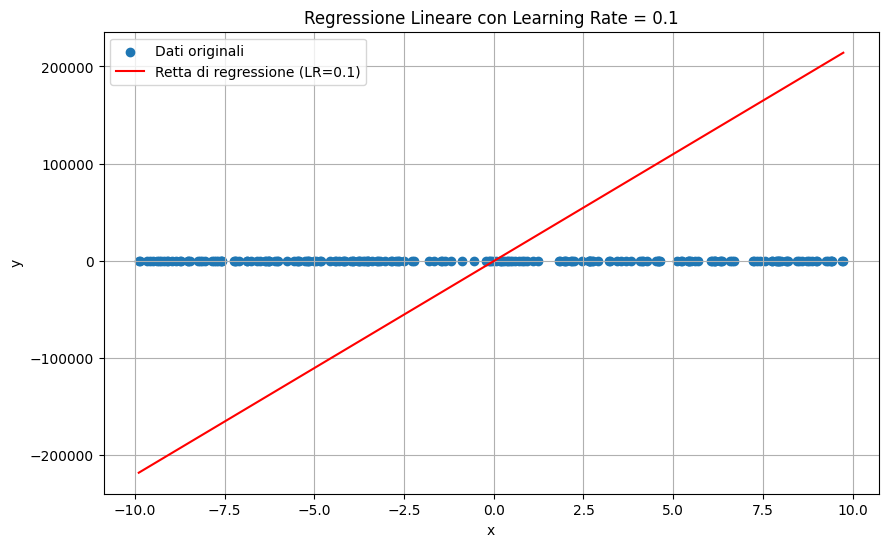

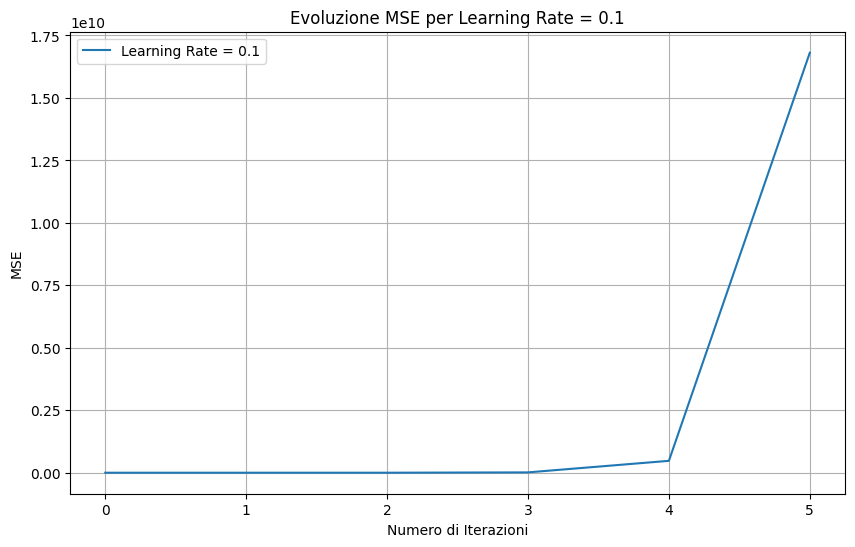

Learning Rate: 1
Divergenza!
MSE iniziale: 330.9423362176781
MSE finale: 31398964530651.82
m: 950989.6690203393
q: -9019.723121740944


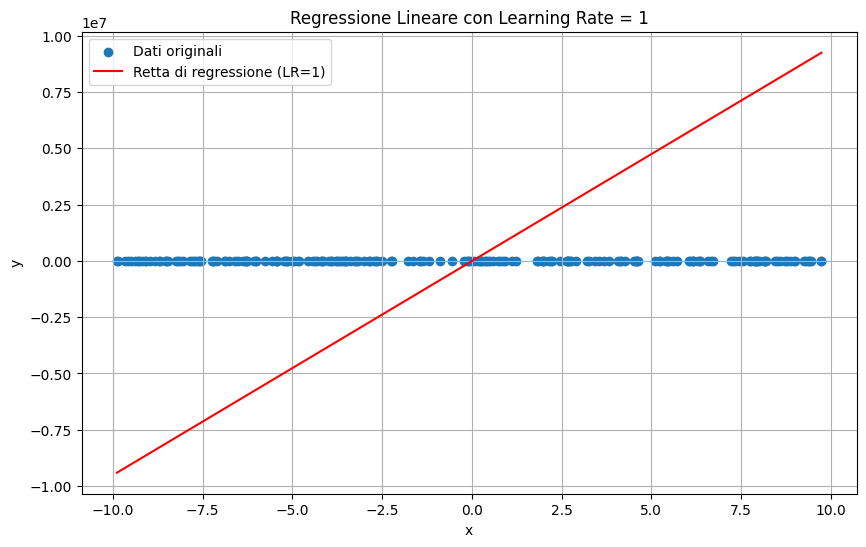

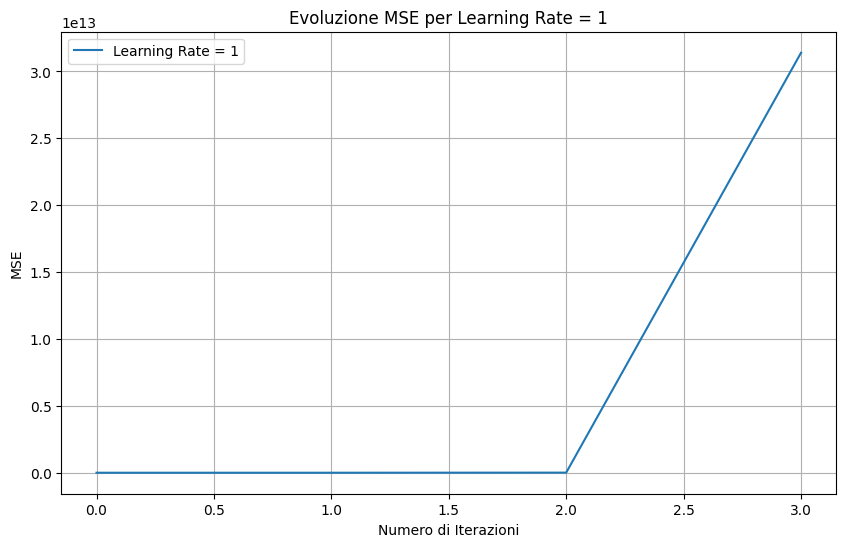

Learning Rate: 10
Divergenza!
MSE iniziale: 330.9423362176781
MSE finale: 70647963420797.95
m: -1426484.6160390165
q: 13047.478013913416


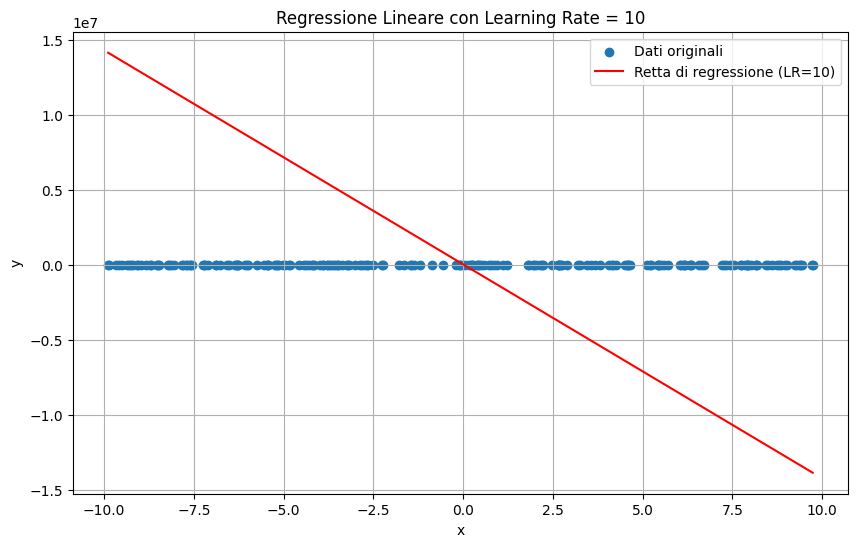

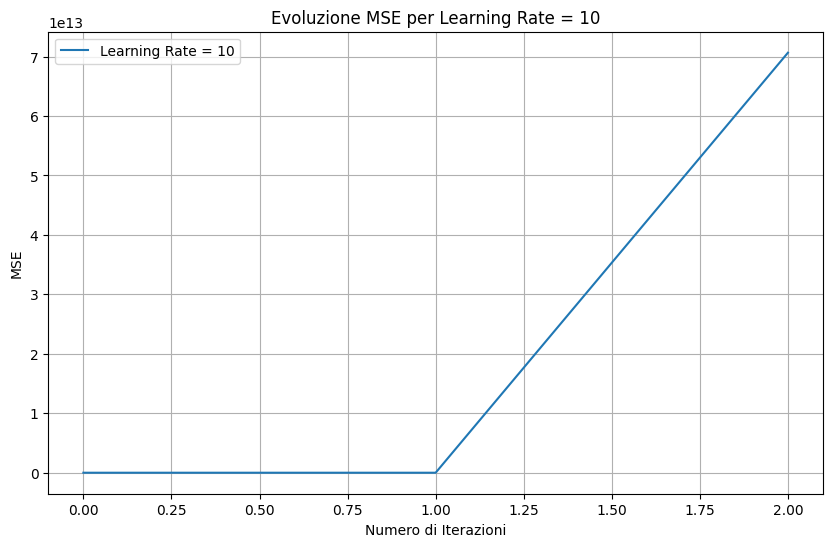

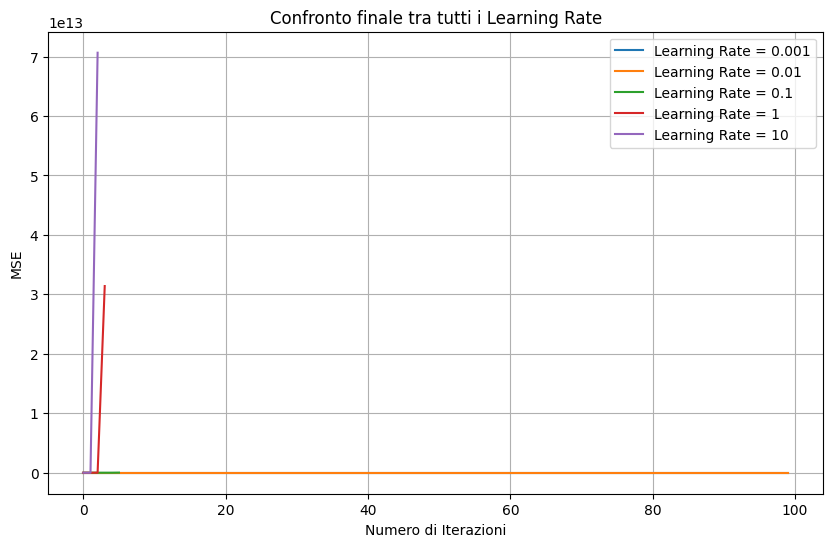

Learning Rate 0.1 -> diverge.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 200

np.random.seed(42)

x = np.random.uniform(-10,10,N)

rumore = np.random.normal(0,5,N)

y = 3 * x + 1 + rumore

#grafico dei dati generati
plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dati generati")
plt.grid()
plt.show()

#elenco dei learning rate richiesti
learning_rates = [0.001, 0.01, 0.1, 1, 10]

tutti_errori = {}

for learning_rate in learning_rates:

  print("Learning Rate:", learning_rate)

  m = 0
  q = 0

  errori = []

  final_y_pred = None

  for i in range(100):

    y_pred = m * x + q

    errore = y_pred - y

    errore_quadratico = errore**2

    somma_errori = np.sum(errore_quadratico)

    MSE = somma_errori / N

    errori.append(MSE)

    if not np.isfinite(MSE):
      print("Divergenza!")
      break

    if MSE > 1e10:
      print("Divergenza!")
      break

    grad_m = (2/N)*np.sum(errore*x)
    grad_q = (2/N)*np.sum(errore)

    m = m - learning_rate * grad_m
    q = q - learning_rate * grad_q

  tutti_errori[learning_rate] = errori
  print("MSE iniziale:", errori[0])
  print("MSE finale:", errori[-1])

  print("m:",m)
  print("q:",q)

  #stampo il grafico per ogni learning rate
  plt.figure(figsize=(10,6))
  plt.scatter(x,y, label='Dati originali')
  line_x = np.array([min(x), max(x)])
  line_y = m * line_x + q
  plt.plot(line_x, line_y, color='red', label=f'Retta di regressione (LR={learning_rate})')
  plt.xlabel("x")
  plt.ylabel("y")
  plt.title(f"Regressione Lineare con Learning Rate = {learning_rate}")
  plt.grid()
  plt.legend()
  plt.show()

  #stampo il cambiamento dell'MSE per ogni learning rate
  plt.figure(figsize=(10,6))
  errori_clean = [e if np.isfinite(e) else np.nan for e in errori]
  plt.plot(errori_clean, label=f"Learning Rate = {learning_rate}")
  plt.xlabel("Numero di Iterazioni")
  plt.ylabel("MSE")
  plt.title(f"Evoluzione MSE per Learning Rate = {learning_rate}")
  plt.grid()
  plt.legend()
  plt.show()

#stampa di tutti i learning rate insieme
plt.figure(figsize=(10,6))
for learning_rate in learning_rates:
  errori = tutti_errori[learning_rate]
  errori_clean = [e if np.isfinite(e) else np.nan for e in errori]
  plt.plot(errori_clean, label=f"Learning Rate = {learning_rate}")

plt.xlabel("Numero di Iterazioni")
plt.ylabel("MSE")
plt.title("Confronto finale tra tutti i Learning Rate")
plt.grid()
plt.legend()
plt.show()

test = np.arange(0.1,2,0.01)

for learning_rate in test:

  m = 0
  q = 0

  diverge = False

  for i in range(100):

    y_pred = m * x + q

    errore = y_pred-y

    errore_quadratico = errore**2

    somma_errori = np.sum(errore_quadratico)

    MSE = somma_errori / N

    if MSE > 1e10:
      diverge = True
      break

    grad_m = (2/N)*np.sum(errore*x)
    grad_q = (2/N)*np.sum(errore)

    m = m - learning_rate * grad_m
    q = q - learning_rate * grad_q

  #stampa da quale learning rate si ha divergenza
  if diverge:
    print(f"Learning Rate {learning_rate} -> diverge.")
    break
  else:
    print(f"Learning Rate {learning_rate} -> stabile")

LEARNING RATE 0.001:

Come si può vedere dal grafico, l'errore diminuisce lentamente nel corso delle iterazioni e si stabilizza dopo un elevato numero di iterazioni.

LEARNING RATE 0.01:

A differenza dal learning rate 0.001, l'errore diminuisce più rapidamente e si stabilizza raggiungendo la soluzione ottimale in tempi minori.

LEARNING RATE 0.1 - 1 - 10:

Come si può vedere anche dalla stampa finale, tutti i learning rate maggiori o uguali a 0.1 divergono. Quindi il valore di soglia per la divergenza è 0.1. L'unica loro differenza sta nella velocità con cui avviene la divergenza. Infatti, con learning rate 0.1 l'errore cresce progressivamente già dopo poche iterazioni, con learning rate 1 la divergenza avviene in modo più veloce, mentre con learning rate 10 la divergenza è quasi immediata.


